In [17]:
import pathlib
import sqlite3
import pandas as pd
import jupedsim as jps
import matplotlib.pyplot as plt
import numpy as np
import pedpy
from shapely import Polygon
import plotly.graph_objects as go  

%matplotlib inline

In [36]:
evac_times = []
widths = []

# 读取Small_A_Width_0.8.sqlite到Small_A_Width_2.4.sqlite这9个文件  
for width in np.arange(1.0, 1.8, 0.2):  
    width = round(width, 1) 
    filename = f"Small_A_Width_{width}.sqlite"  
    
    try:  
        conn = sqlite3.connect(filename)  
        df = pd.read_sql_query("SELECT * FROM trajectory_data", conn)  
        conn.close()  
        
        t_evac = df['frame'].max() * 0.1  # 假设时间步长0.1秒  
        evac_times.append(t_evac)  
        widths.append(width)  
        
    except Exception as e:
        print(f"读取{filename}失败: {e}")  

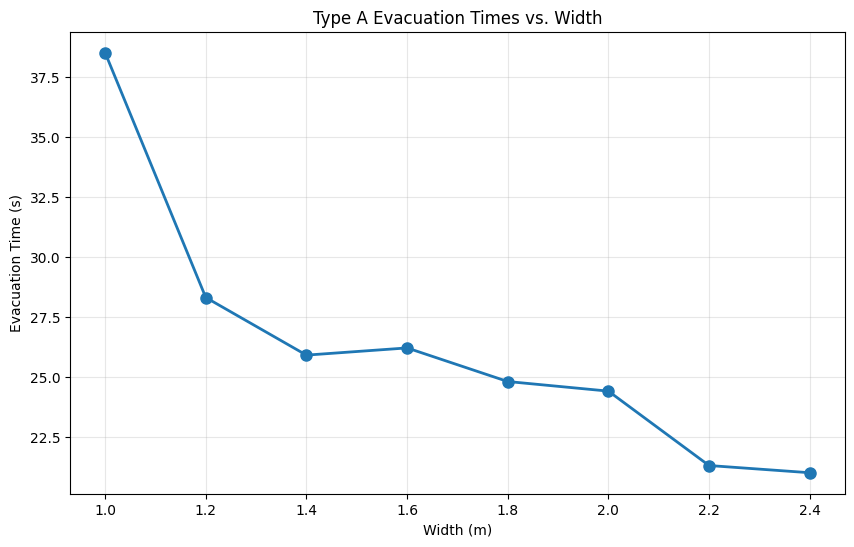

In [37]:
plt.figure(figsize=(10, 6))  
plt.plot(widths, evac_times, 'o-', linewidth=2, markersize=8)  
plt.xlabel('Width (m)')  
plt.ylabel('Evacuation Time (s)')  
plt.title('Type A Evacuation Times vs. Width')  
plt.grid(True, alpha=0.3)  
plt.show()

In [38]:
B_evac_times = []
B_widths = []

# 读取Small_A_Width_0.8.sqlite到Small_A_Width_2.4.sqlite这9个文件  
for width in np.arange(1.0, 2.6, 0.2):  
    width = round(width, 1) 
    filename = f"Small_B_Width_{width}.sqlite"  
    
    try:  
        conn = sqlite3.connect(filename)  
        df = pd.read_sql_query("SELECT * FROM trajectory_data", conn)  
        conn.close()  
        
        t_evac = df['frame'].max() * 0.1  # 假设时间步长0.1秒  
        B_evac_times.append(t_evac)  
        B_widths.append(width)  
        
    except Exception as e:  
        print(f"读取{filename}失败: {e}")  

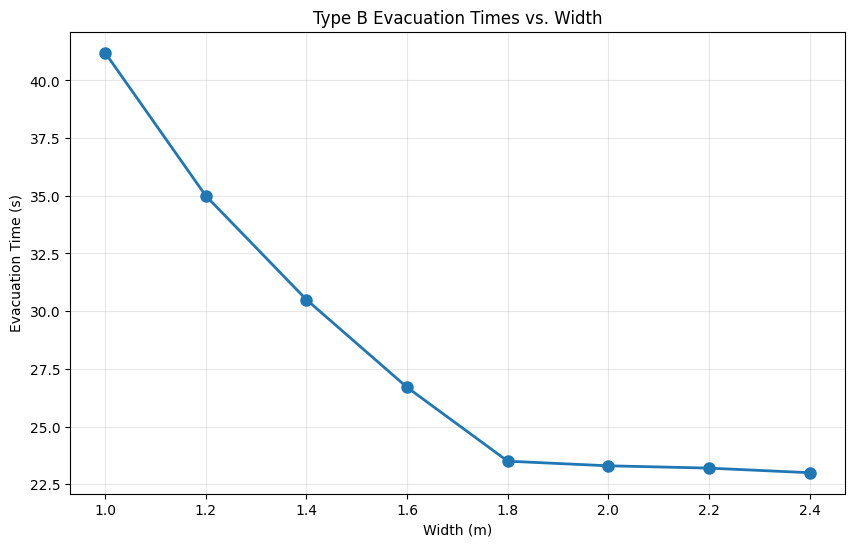

In [39]:
plt.figure(figsize=(10, 6))  
plt.plot(B_widths, B_evac_times, 'o-', linewidth=2, markersize=8)  
plt.xlabel('Width (m)')  
plt.ylabel('Evacuation Time (s)')  
plt.title('Type B Evacuation Times vs. Width')  
plt.grid(True, alpha=0.3)  
plt.show()

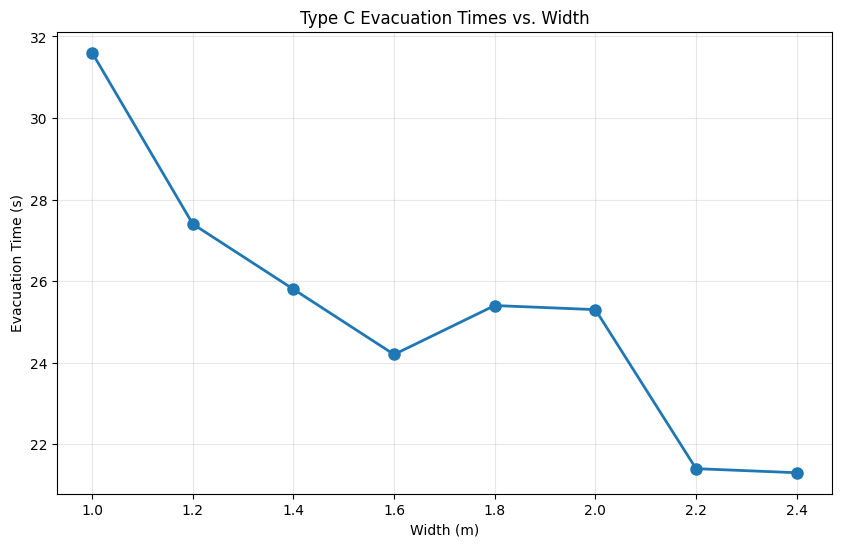

In [42]:
C_evac_times = []
C_widths = []

# 读取Small_A_Width_0.8.sqlite到Small_A_Width_2.4.sqlite这9个文件  
for width in np.arange(1.0, 2.6, 0.2):  
    width = round(width, 1) 
    filename = f"Small_C_Width_{width}.sqlite"  
    
    try:  
        conn = sqlite3.connect(filename)  
        df = pd.read_sql_query("SELECT * FROM trajectory_data", conn)  
        conn.close()  
        
        t_evac = df['frame'].max() * 0.1  # 假设时间步长0.1秒  
        C_evac_times.append(t_evac)  
        C_widths.append(width)  
        
    except Exception as e:  
        print(f"读取{filename}失败: {e}")  
        
plt.figure(figsize=(10, 6))  
plt.plot(C_widths, C_evac_times, 'o-', linewidth=2, markersize=8)  
plt.xlabel('Width (m)')  
plt.ylabel('Evacuation Time (s)')  
plt.title('Type C Evacuation Times vs. Width')  
plt.grid(True, alpha=0.3)  
plt.show()

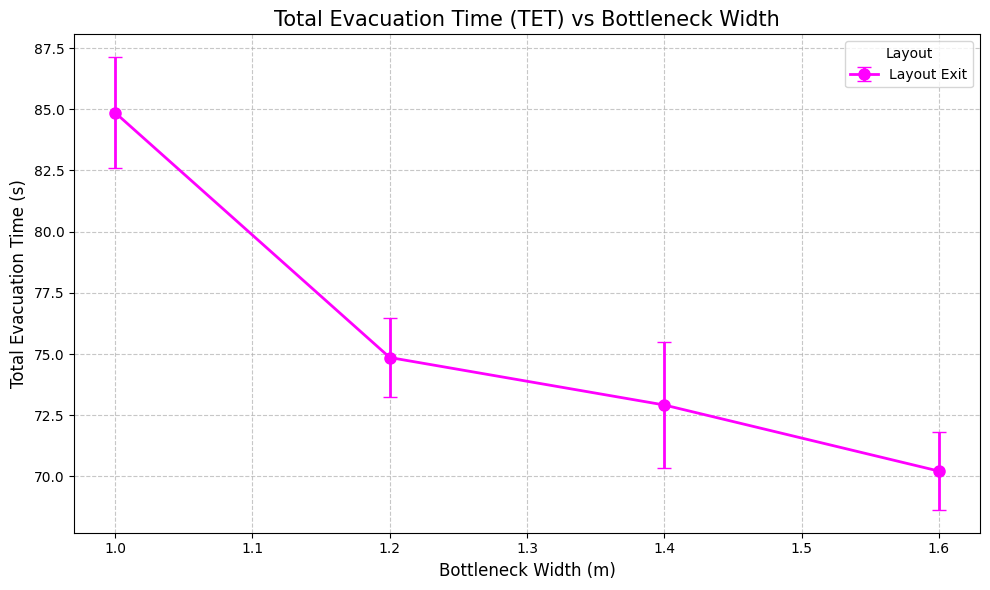

In [6]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_tet(filepath, time_step=0.1):
    try:
        # 连接数据库
        conn = sqlite3.connect(filepath)
        
        # 读取轨迹数据
        df = pd.read_sql_query("SELECT * FROM trajectory_data", conn)
        conn.close()
        
        # 检查必要字段
        if 'frame' not in df.columns:
            print(f"警告：{filepath} 缺少 'frame' 字段")
            return np.nan
        
        # 计算 TET：最后一帧的时间
        tet = df['frame'].max() * time_step
        
        return tet
    
    except Exception as e:
        print(f"处理 {filepath} 时发生错误: {e}")
        return np.nan

def process_small_tet():
    base_path = "Big_Average"
    layouts = ["Exit"]
    widths = [round(w * 0.2 + 1.0, 1) for w in range(0, 4)]  # 1.0 - 2.0 m
    runs = list(range(5))
    
    results = {layout: {} for layout in layouts}
    std_results = {layout: {} for layout in layouts}
    
    for layout in layouts:
        layout_path = os.path.join(base_path, layout)
        for width in widths:
            tet_runs = []
            for run in runs:
                filename = f"Width_{width:.1f}_{run}.sqlite"
                filepath = os.path.join(layout_path, filename)
                
                if os.path.exists(filepath):
                    tet = calculate_tet(filepath)
                    tet_runs.append(tet)
                else:
                    print(f"文件不存在: {filepath}")
            
            # 计算该 width 下的 TET 均值和标准差
            results[layout][width] = np.mean(tet_runs) if tet_runs else np.nan
            std_results[layout][width] = np.std(tet_runs) if tet_runs else np.nan
    
    return results, std_results

def plot_tet_width():
    
    # 获取数据
    tet_means, tet_stds = process_small_tet()
    
    # 创建图形
    plt.figure(figsize=(10, 6))
    
    # 定义颜色和标记
    #colors = {'A': 'blue', 'B': 'green', 'C': 'red', 'A2':'cyan','B2':'SpringGreen','C2':'pink' }
    #markers = {'A': 'o', 'B': 's', 'C': '^', 'A2':'o','B2':'s','C2':'^'}
    colors = {'Exit':'Magenta','MultiRoom':'Cyan'}
    markers = {'Exit': 'o'}
    # 绘制每个布局的折线
    for layout in ['Exit']:
        widths = list(tet_means[layout].keys())
        means = list(tet_means[layout].values())
        stds = list(tet_stds[layout].values())
        
        plt.errorbar(widths, means, 
                     yerr=stds, 
                     label=f'Layout {layout}', 
                     color=colors[layout], 
                     marker=markers[layout], 
                     capsize=5, 
                     linestyle='-', 
                     linewidth=2, 
                     markersize=8)
    
    plt.title('Total Evacuation Time (TET) vs Bottleneck Width', fontsize=15)
    plt.xlabel('Bottleneck Width (m)', fontsize=12)
    plt.ylabel('Total Evacuation Time (s)', fontsize=12)
    plt.legend(title='Layout', loc='best')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 保存图像
    plt.tight_layout()
    plt.savefig('data/processed/tet_vs_Bottleneck.png', dpi=300)
    plt.show()

# 执行绘图
plot_tet_width()



绘制 Seaborn 热力图...


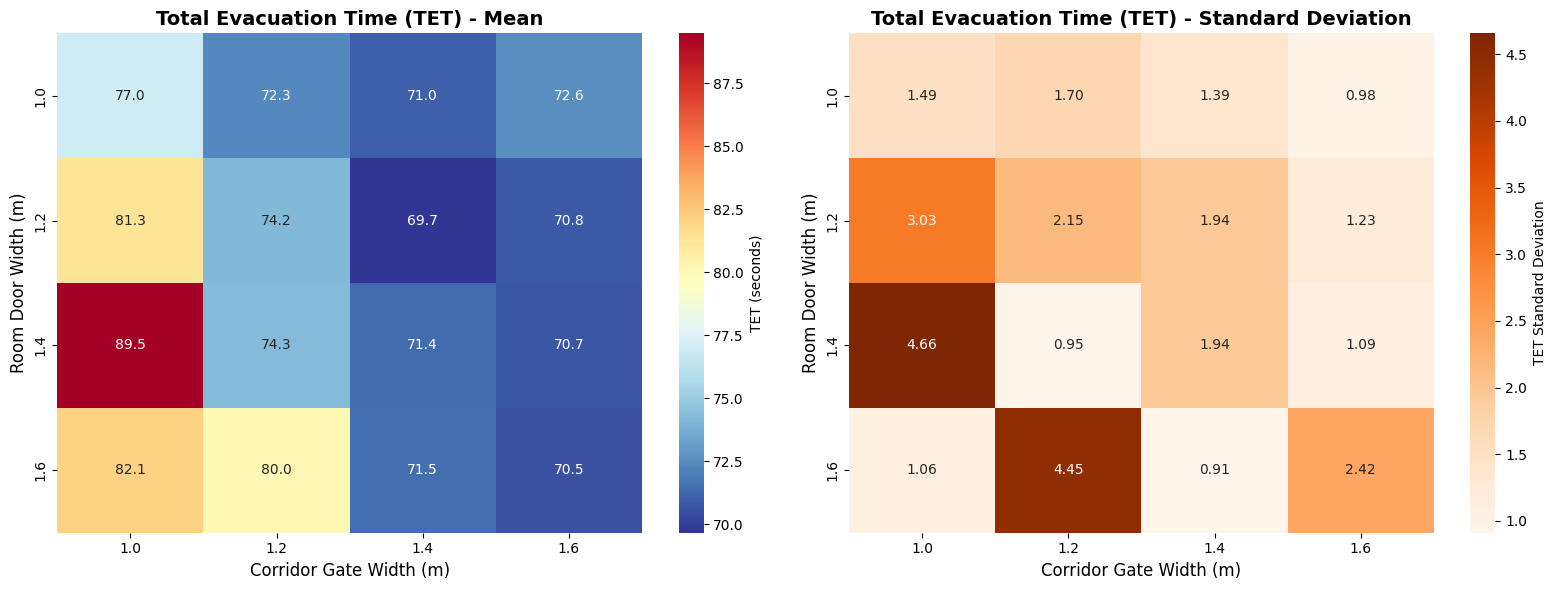


数据统计:
         Width1    Width2   TET_Mean    TET_Std
count  16.00000  16.00000  16.000000  16.000000
mean    1.30000   1.30000  74.925000   1.962089
std     0.23094   0.23094   5.594833   1.173851
min     1.00000   1.00000  69.660000   0.910824
25%     1.15000   1.15000  70.940000   1.083454
50%     1.30000   1.30000  72.460000   1.592568
75%     1.45000   1.45000  77.755000   2.216227
max     1.60000   1.60000  89.480000   4.657639


In [16]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_tet(filepath, time_step=0.1):
    try:
        # 连接数据库
        conn = sqlite3.connect(filepath)
        
        # 读取轨迹数据
        df = pd.read_sql_query("SELECT * FROM trajectory_data", conn)
        conn.close()
        
        # 检查必要字段
        if 'frame' not in df.columns:
            print(f"警告：{filepath} 缺少 'frame' 字段")
            return np.nan
        
        # 计算 TET：最后一帧的时间
        tet = df['frame'].max() * time_step
        
        return tet
    
    except Exception as e:
        print(f"处理 {filepath} 时发生错误: {e}")
        return np.nan

def process_multiroom_tet():
    base_path = "Big_Average"
    layouts = ["MultiRoom"]
    width1_values = np.arange(1.0, 1.8, 0.2)  # [1.0, 1.2, 1.4, 1.6]
    width2_values = np.arange(1.0, 1.8, 0.2)  # [1.0, 1.2, 1.4, 1.6]
    runs = list(range(5))
    
    results = {}
    std_results = {}
    
    for layout in layouts:
        layout_path = os.path.join(base_path, layout)
        results[layout] = {}
        std_results[layout] = {}
        
        for width1 in width1_values:
            width1 = round(width1, 1)
            for width2 in width2_values:
                width2 = round(width2, 1)
                
                tet_runs = []
                for run in runs:
                    filename = f"Width_{width1:.1f}_{width2:.1f}_{run}.sqlite"
                    filepath = os.path.join(layout_path, filename)
                    
                    if os.path.exists(filepath):
                        tet = calculate_tet(filepath)
                        if not np.isnan(tet):
                            tet_runs.append(tet)
                    else:
                        print(f"文件不存在: {filepath}")
                
                # 计算该 width1-width2 组合下的 TET 均值和标准差
                width_key = f"{width1:.1f}_{width2:.1f}"
                results[layout][width_key] = np.mean(tet_runs) if tet_runs else np.nan
                std_results[layout][width_key] = np.std(tet_runs) if tet_runs else np.nan
    
    return results, std_results, width1_values, width2_values

def plot_tet_heatmap():
    """绘制 TET 热力图"""
    # 获取数据
    tet_means, tet_stds, width1_values, width2_values = process_multiroom_tet()
    
    layout = "MultiRoom"
    
    # 创建矩阵
    width1_rounded = [round(w, 1) for w in width1_values]
    width2_rounded = [round(w, 1) for w in width2_values]
    
    # 构建 TET 矩阵和标准差矩阵
    tet_matrix = np.full((len(width1_rounded), len(width2_rounded)), np.nan)
    std_matrix = np.full((len(width1_rounded), len(width2_rounded)), np.nan)
    
    for i, w1 in enumerate(width1_rounded):
        for j, w2 in enumerate(width2_rounded):
            key = f"{w1:.1f}_{w2:.1f}"
            if key in tet_means[layout]:
                tet_matrix[i, j] = tet_means[layout][key]
                std_matrix[i, j] = tet_stds[layout][key]
    
    # 创建图形
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 热力图1：TET均值
    im1 = ax1.imshow(tet_matrix, cmap='RdYlBu_r', aspect='auto')
    ax1.set_title('Total Evacuation Time (TET) - Mean', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Width2 (m)', fontsize=12)
    ax1.set_ylabel('Width1 (m)', fontsize=12)
    
    # 设置坐标轴标签
    ax1.set_xticks(range(len(width2_rounded)))
    ax1.set_xticklabels([f'{w:.1f}' for w in width2_rounded])
    ax1.set_yticks(range(len(width1_rounded)))
    ax1.set_yticklabels([f'{w:.1f}' for w in width1_rounded])
    
    # 添加数值标注
    for i in range(len(width1_rounded)):
        for j in range(len(width2_rounded)):
            if not np.isnan(tet_matrix[i, j]):
                ax1.text(j, i, f'{tet_matrix[i, j]:.1f}', 
                        ha='center', va='center', fontsize=10, fontweight='bold')
    
    # 添加颜色条
    cbar1 = plt.colorbar(im1, ax=ax1)
    cbar1.set_label('TET (seconds)', fontsize=12)
    
    # 热力图2：标准差
    im2 = ax2.imshow(std_matrix, cmap='Oranges', aspect='auto')
    ax2.set_title('Total Evacuation Time (TET) - Standard Deviation', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Width2 (m)', fontsize=12)
    ax2.set_ylabel('Width1 (m)', fontsize=12)
    
    # 设置坐标轴标签
    ax2.set_xticks(range(len(width2_rounded)))
    ax2.set_xticklabels([f'{w:.1f}' for w in width2_rounded])
    ax2.set_yticks(range(len(width1_rounded)))
    ax2.set_yticklabels([f'{w:.1f}' for w in width1_rounded])
    
    # 添加数值标注
    for i in range(len(width1_rounded)):
        for j in range(len(width2_rounded)):
            if not np.isnan(std_matrix[i, j]):
                ax2.text(j, i, f'{std_matrix[i, j]:.2f}', 
                        ha='center', va='center', fontsize=10, fontweight='bold')
    
    # 添加颜色条
    cbar2 = plt.colorbar(im2, ax=ax2)
    cbar2.set_label('TET Standard Deviation', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('data/processed/tet_heatmap_multiroom.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_tet_seaborn_heatmap():
    """使用 Seaborn 绘制更美观的热力图"""
    # 获取数据
    tet_means, tet_stds, width1_values, width2_values = process_multiroom_tet()
    
    layout = "MultiRoom"
    width1_rounded = [round(w, 1) for w in width1_values]
    width2_rounded = [round(w, 1) for w in width2_values]
    
    # 构建 DataFrame
    data_for_heatmap = []
    for i, w1 in enumerate(width1_rounded):
        for j, w2 in enumerate(width2_rounded):
            key = f"{w1:.1f}_{w2:.1f}"
            if key in tet_means[layout] and not np.isnan(tet_means[layout][key]):
                data_for_heatmap.append({
                    'Width1': w1,
                    'Width2': w2,
                    'TET_Mean': tet_means[layout][key],
                    'TET_Std': tet_stds[layout][key]
                })
    
    df_heatmap = pd.DataFrame(data_for_heatmap)
    
    if df_heatmap.empty:
        print("没有有效数据用于绘制热力图")
        return
    
    # 创建透视表
    pivot_mean = df_heatmap.pivot(index='Width1', columns='Width2', values='TET_Mean')
    pivot_std = df_heatmap.pivot(index='Width1', columns='Width2', values='TET_Std')
    
    # 创建图形
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 热力图1：TET均值
    sns.heatmap(pivot_mean, annot=True, fmt='.1f', cmap='RdYlBu_r', 
                ax=ax1, cbar_kws={'label': 'TET (seconds)'})
    ax1.set_title('Total Evacuation Time (TET) - Mean', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Corridor Gate Width (m)', fontsize=12)
    ax1.set_ylabel('Room Door Width (m)', fontsize=12)
    
    # 热力图2：标准差
    sns.heatmap(pivot_std, annot=True, fmt='.2f', cmap='Oranges', 
                ax=ax2, cbar_kws={'label': 'TET Standard Deviation'})
    ax2.set_title('Total Evacuation Time (TET) - Standard Deviation', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Corridor Gate Width (m)', fontsize=12)
    ax2.set_ylabel('Room Door Width (m)', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('data/processed/tet_seaborn_heatmap_multiroom.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return df_heatmap

# 执行绘图
#print("绘制基础热力图...")
#plot_tet_heatmap()

print("\n绘制 Seaborn 热力图...")
df_data = plot_tet_seaborn_heatmap()

if df_data is not None and not df_data.empty:
    print("\n数据统计:")
    print(df_data.describe())


In [9]:
def plot_tet_3d_surface():
    """绘制 3D 表面图"""
    from mpl_toolkits.mplot3d import Axes3D
    
    # 获取数据
    tet_means, tet_stds, width1_values, width2_values = process_multiroom_tet()
    
    layout = "MultiRoom"
    width1_rounded = [round(w, 1) for w in width1_values]
    width2_rounded = [round(w, 1) for w in width2_values]
    
    # 构建网格
    W1, W2 = np.meshgrid(width1_rounded, width2_rounded)
    TET = np.full_like(W1, np.nan)
    
    for i, w1 in enumerate(width1_rounded):
        for j, w2 in enumerate(width2_rounded):
            key = f"{w1:.1f}_{w2:.1f}"
            if key in tet_means[layout]:
                TET[j, i] = tet_means[layout][key]  # 注意索引顺序
    
    # 创建3D图形
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 绘制表面
    surface = ax.plot_surface(W1, W2, TET, cmap='RdYlBu_r', alpha=0.8)
    
    ax.set_title('Total Evacuation Time (TET) - 3D Surface', fontsize=14, fontweight='bold')
    ax.set_xlabel('Width1 (m)', fontsize=12)
    ax.set_ylabel('Width2 (m)', fontsize=12)
    ax.set_zlabel('TET (seconds)', fontsize=12)
    
    # 添加颜色条
    fig.colorbar(surface, ax=ax, label='TET (seconds)')
    
    plt.tight_layout()
    plt.savefig('data/processed/tet_3d_surface_multiroom.png', dpi=300, bbox_inches='tight')
    plt.show()


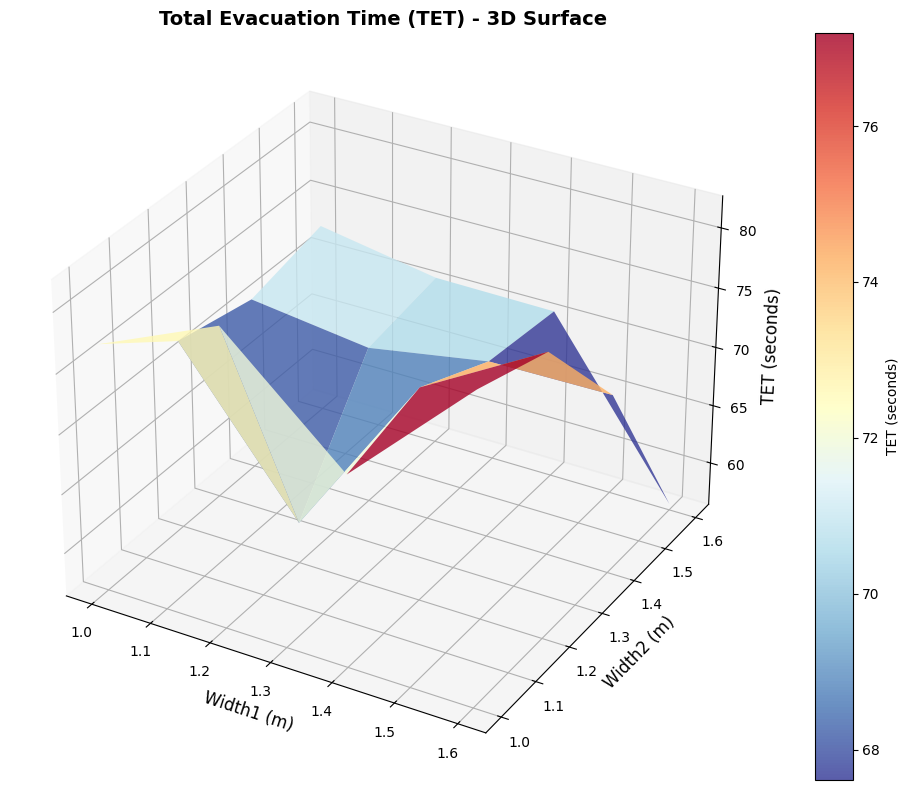

In [10]:
plot_tet_3d_surface()

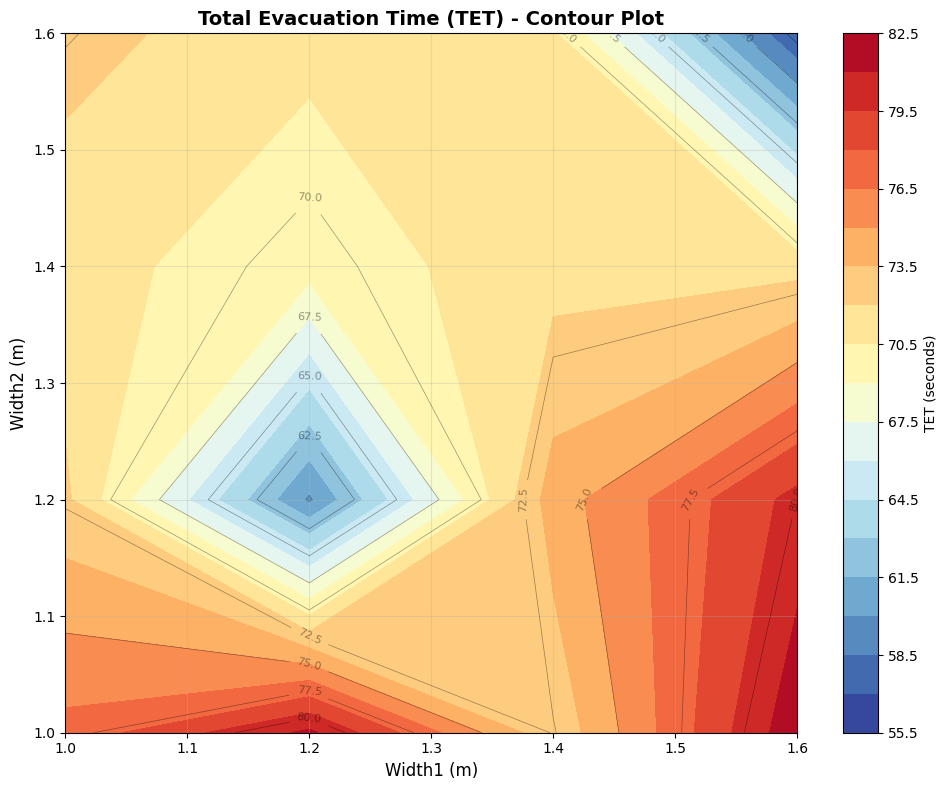

In [11]:
def plot_tet_contour():
    """绘制等高线图"""
    # 获取数据
    tet_means, tet_stds, width1_values, width2_values = process_multiroom_tet()
    
    layout = "MultiRoom"
    width1_rounded = [round(w, 1) for w in width1_values]
    width2_rounded = [round(w, 1) for w in width2_values]
    
    # 构建网格
    W1, W2 = np.meshgrid(width1_rounded, width2_rounded)
    TET = np.full_like(W1, np.nan)
    
    for i, w1 in enumerate(width1_rounded):
        for j, w2 in enumerate(width2_rounded):
            key = f"{w1:.1f}_{w2:.1f}"
            if key in tet_means[layout]:
                TET[j, i] = tet_means[layout][key]
    
    # 创建等高线图
    plt.figure(figsize=(10, 8))
    contour = plt.contourf(W1, W2, TET, levels=20, cmap='RdYlBu_r')
    plt.colorbar(contour, label='TET (seconds)')
    
    # 添加等高线
    contour_lines = plt.contour(W1, W2, TET, levels=10, colors='black', alpha=0.4, linewidths=0.5)
    plt.clabel(contour_lines, inline=True, fontsize=8)
    
    plt.title('Total Evacuation Time (TET) - Contour Plot', fontsize=14, fontweight='bold')
    plt.xlabel('Width1 (m)', fontsize=12)
    plt.ylabel('Width2 (m)', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('data/processed/tet_contour_multiroom.png', dpi=300, bbox_inches='tight')
    plt.show()


plot_tet_contour()
